# Word frequency in english

In [2]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

import pandas as pd 

import sys

sys.path.append('../')
import germibeta as G

/home/sergio/trabajo/fbc/tests/../germibeta.py:276: SyntaxWarning: invalid escape sequence '\l'
  graf_datos(F, params, {'titulo':'FBC ejemplo', 'eje_x': 'Rank', 'eje_y':'\log(f)'},'fbc')


In [3]:
path_words = '../data/tabla_palabras.csv'

The dataset `words` has a sample of words in english and its associated frequency of use. We can se its distribution

In [4]:
df_words = pd.read_csv(path_words)
df_words

,palabra,freq
0,the,69971
1,of,36412
2,and,28854
3,to,26164
4,a,23338
...,...,...
46270,eightynine,1
46271,pigen,1
46272,northerly,1
46273,lawuntoitself,1


<Axes: >

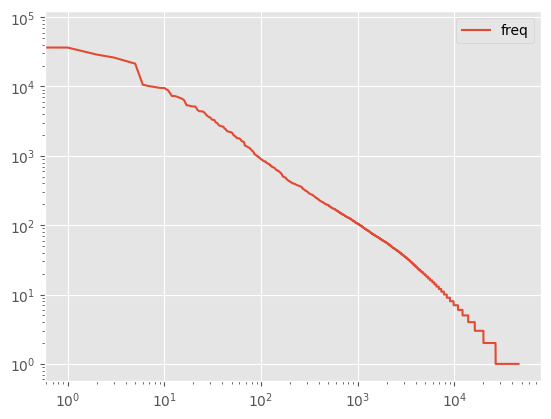

In [5]:
df_words.plot(loglog=True)

## Power law fit

In [6]:
# Define power law model: y = a * x^b
def power_law(x, a, b):
    return a * np.power(x, b)

# Sort by frequency descending and assign rank
df_sorted = df_words.sort_values('freq', ascending=False).reset_index(drop=True)
df_sorted['rank'] = df_sorted.index + 1  # rank starts at 1
x = df_sorted['rank'].values.astype(float)
y = df_sorted['freq'].values.astype(float)

# Fit the data
popt, pcov = curve_fit(power_law, x, y, p0=[1, -1])
a, b = popt

/tmp/ipykernel_218426/711647917.py:3: RuntimeWarning: overflow encountered in power
  return a * np.power(x, b)
/tmp/ipykernel_218426/711647917.py:3: RuntimeWarning: overflow encountered in multiply
  return a * np.power(x, b)


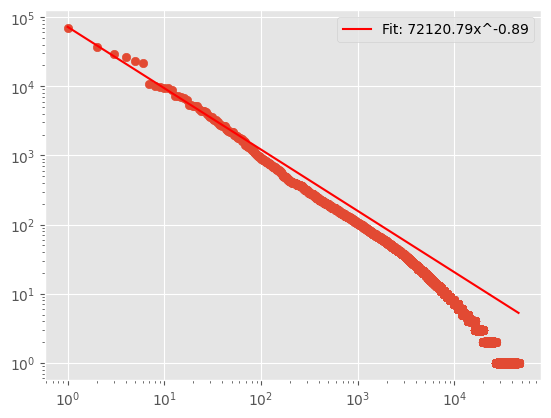

In [7]:
# Plot results
plt.scatter(x, y)
plt.loglog(x, power_law(x, *popt), 'r-', label=f'Fit: {a:.2f}x^{b:.2f}')
plt.legend()
plt.show()   

## Beta Cocho fit 

Using the same data but now with de `fbc` fit with uses a semilog transform and tries to fit two main parameters

In [12]:
# just in case you datafrme is not properly ordered in descending order 
df_words.sort_values('freq', ascending=False)

,palabra,freq
0,the,69971
1,of,36412
2,and,28854
3,to,26164
4,a,23338
...,...,...
33256,selfimage,1
33255,existentialism,1
33254,eidetic,1
33253,vesuvios,1


In [22]:
gg = G.Germibeta()
# gg.carga_archivo('../data/tabla_palabras.csv', header=['palabra','freq'])

The method to make the fit is `ajuste` with parameter `F` to set the data. This method has one parameter 
to set the method of fit.

The output is an array wich has the following values 
```python
[alpha, beta, A, N, r2]
```




In [23]:
gg.ajuste(F=df_words['freq'])

[1.3317436588495433,
 -0.006319360826144149,
 1387508.435450428,
 46275,
 0.97352866903728]

We can get the values of the last fit through `params` method

In [24]:
gg.params

[1.3317436588495433,
 -0.006319360826144149,
 1387508.435450428,
 46275,
 0.97352866903728]

In [37]:
y=df_words['freq'].array
G.graf_datos(y,
             gg.params, 
             {'titulo' : 'English word frequency',
              'eje_x' : 'Word', 
              'eje_y' : r'$\log(f)$'},'word.png')

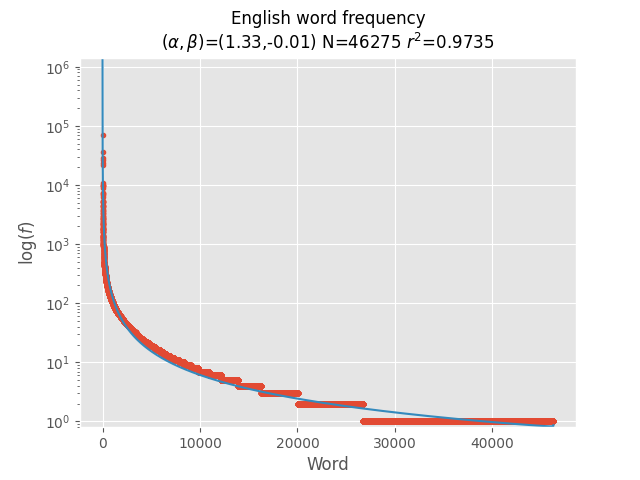

In [38]:
from IPython.display import Image, display
display(Image(filename='./word.png'))   